<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


 ## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage. 

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


----


Install the below libraries


In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab 



In [2]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis 


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [3]:
df = pd.read_csv("dataset_part_2.csv")
df.head(5)

,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Version Booster,Booster landing,Date,Time,Class
0,1,CCAFS,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,F9 v1.07B0003.1,Failure,4 June 2010,18:45,0
1,2,CCAFS,Dragon,0,LEO,NASA,Success,F9 v1.07B0004.1,Failure,8 December 2010,15:43,0
2,3,CCAFS,Dragon,525 kg,LEO,NASA,Success,F9 v1.07B0005.1,No,22 May 2012,07:44,1
3,4,CCAFS,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success,F9 v1.07B0006.1,No attempt,8 October 2012,00:35,1
4,5,CCAFS,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success,F9 v1.07B0007.1,No,1 March 2013,15:10,1


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


In [4]:
df.columns

Index(['Flight No.', 'Launch site', 'Payload', 'Payload mass', 'Orbit',
       'Customer', 'Launch outcome', 'Version Booster', 'Booster landing',
       'Date', 'Time', 'Class'],
      dtype='object')

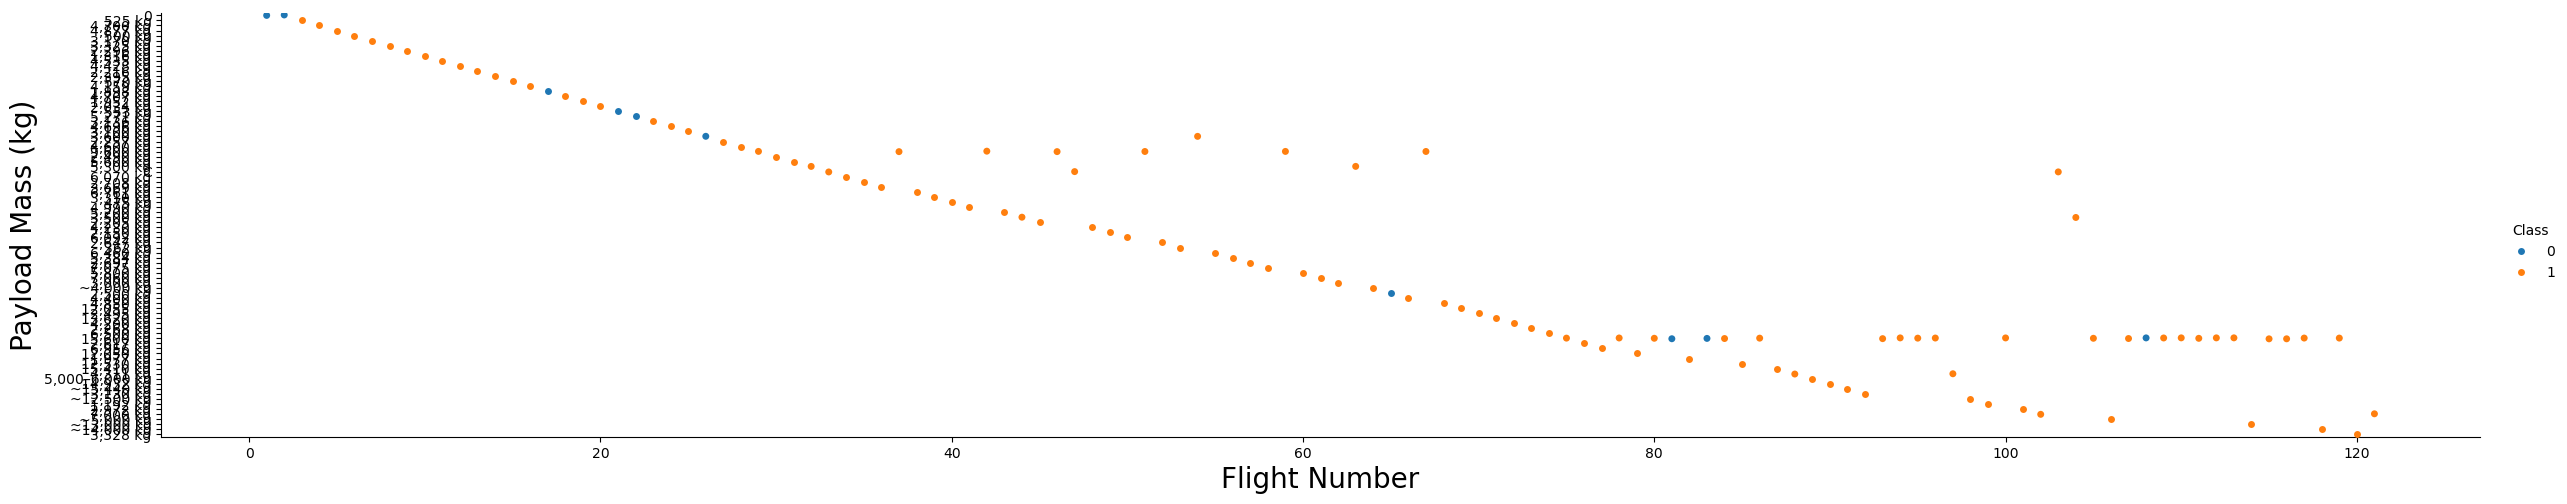

In [6]:
sns.catplot(
    y="Payload mass",
    x="Flight No.",
    hue="Class",
    data=df,
    aspect=5
)

plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Payload Mass (kg)", fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


Text(32.653847916666635, 0.5, 'Launch Site')

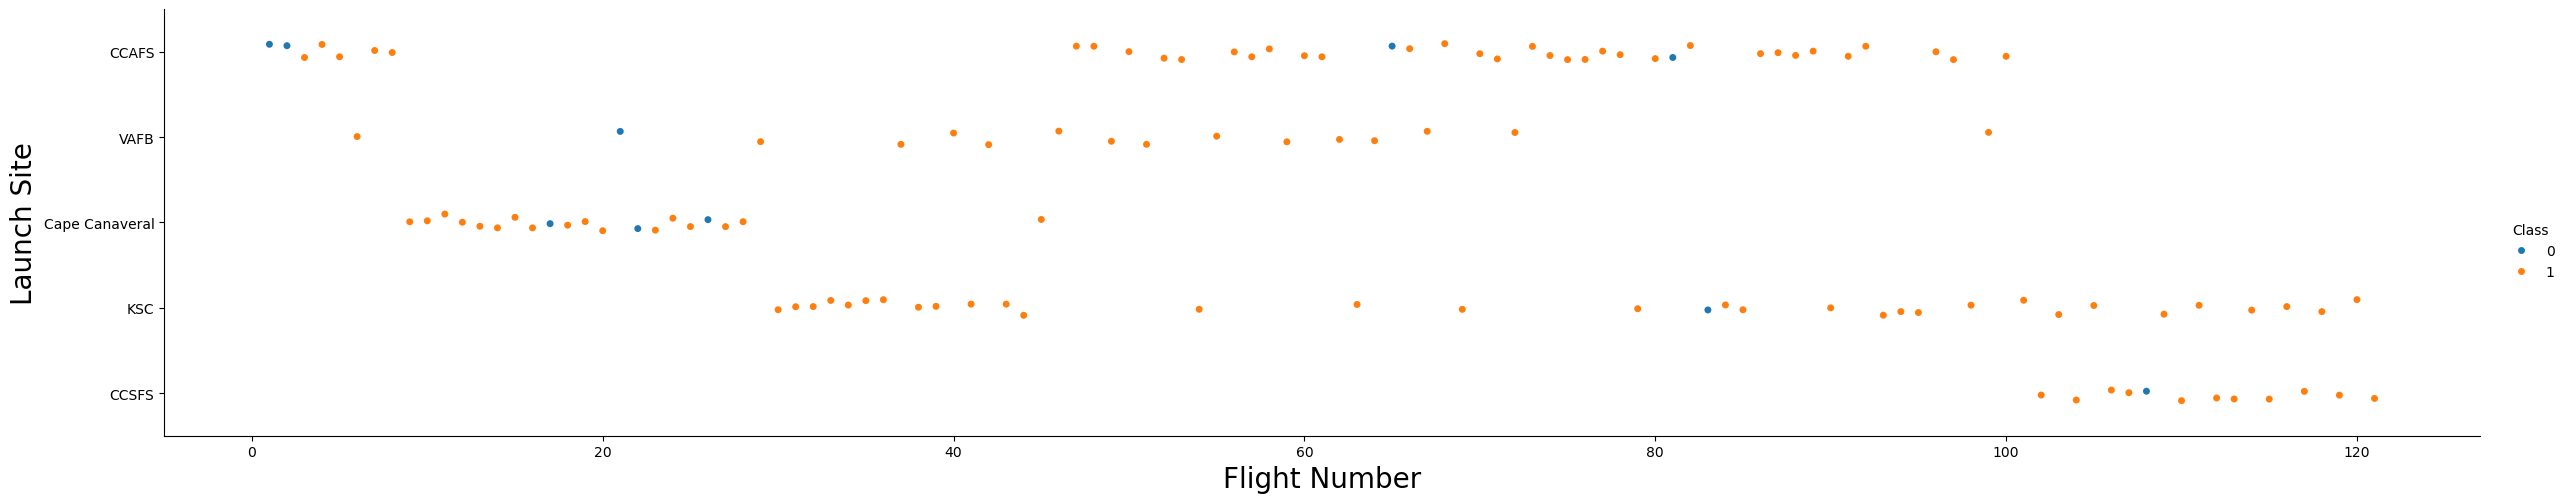

In [5]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(
    x="Flight No.",
    y="Launch site",
    hue="Class",
    data=df,
    kind="strip",
    aspect=5
)

plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)


In [6]:
plt.figure(figsize=(8, 6))
plt.savefig('scatter.png', dpi=300, bbox_inches='tight')
scatter.png

NameError: name 'scatter' is not defined

<Figure size 800x600 with 0 Axes>

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


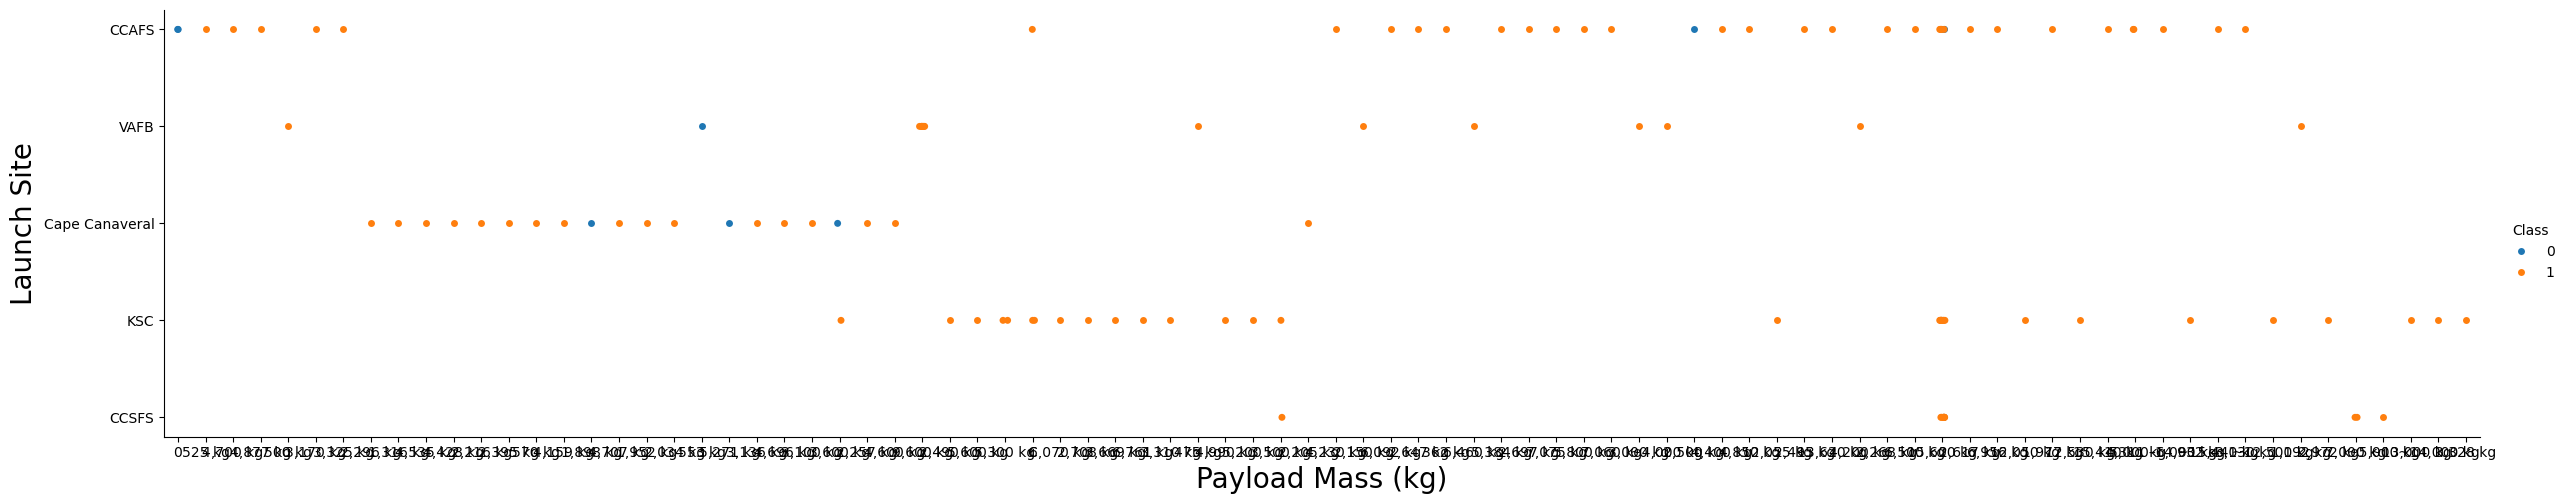

In [9]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.catplot(
    x="Payload mass",
    y="Launch site",
    hue="Class",
    data=df,
    kind="strip",
    aspect=5
)

plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


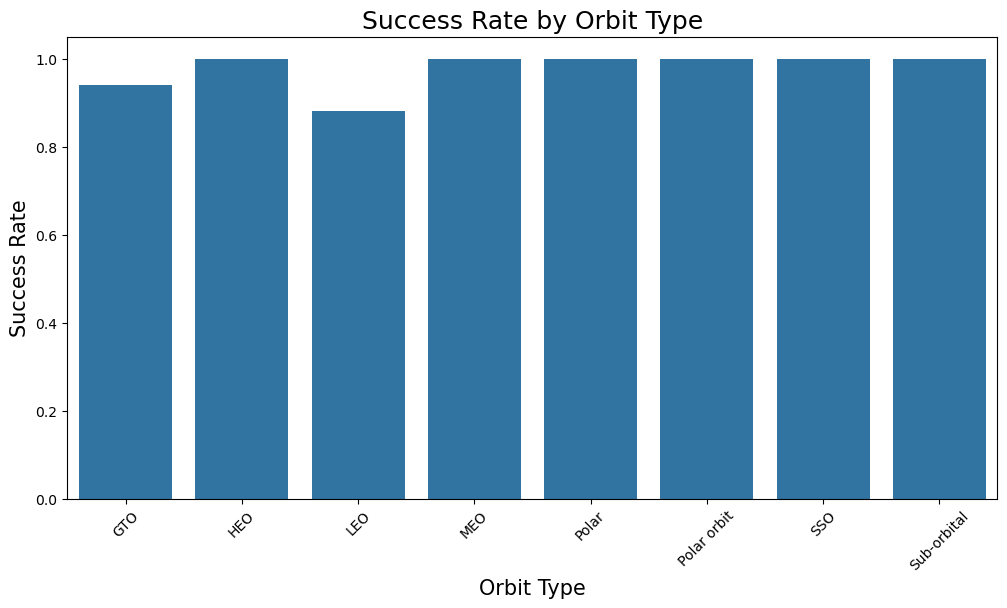

In [10]:
# HINT use groupby method on Orbit column and get the mean of Class column
# Calculate success rate by orbit type
orbit_success_rate = df.groupby("Orbit")["Class"].mean().reset_index()

# Plot bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x="Orbit",
    y="Class",
    data=orbit_success_rate
)

plt.xlabel("Orbit Type", fontsize=15)
plt.ylabel("Success Rate", fontsize=15)
plt.title("Success Rate by Orbit Type", fontsize=18)
plt.xticks(rotation=45)

plt.show()

Analyze the ploted bar chart try to find which orbits have high sucess rate.

In [11]:
orbit_success_rate.sort_values(by="Class", ascending=False)

,Orbit,Class
1,HEO,1.000000
3,MEO,1.000000
4,Polar,1.000000
5,Polar orbit,1.000000
6,SSO,1.000000
7,Sub-orbital,1.000000
0,GTO,0.939394
2,LEO,0.880597


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


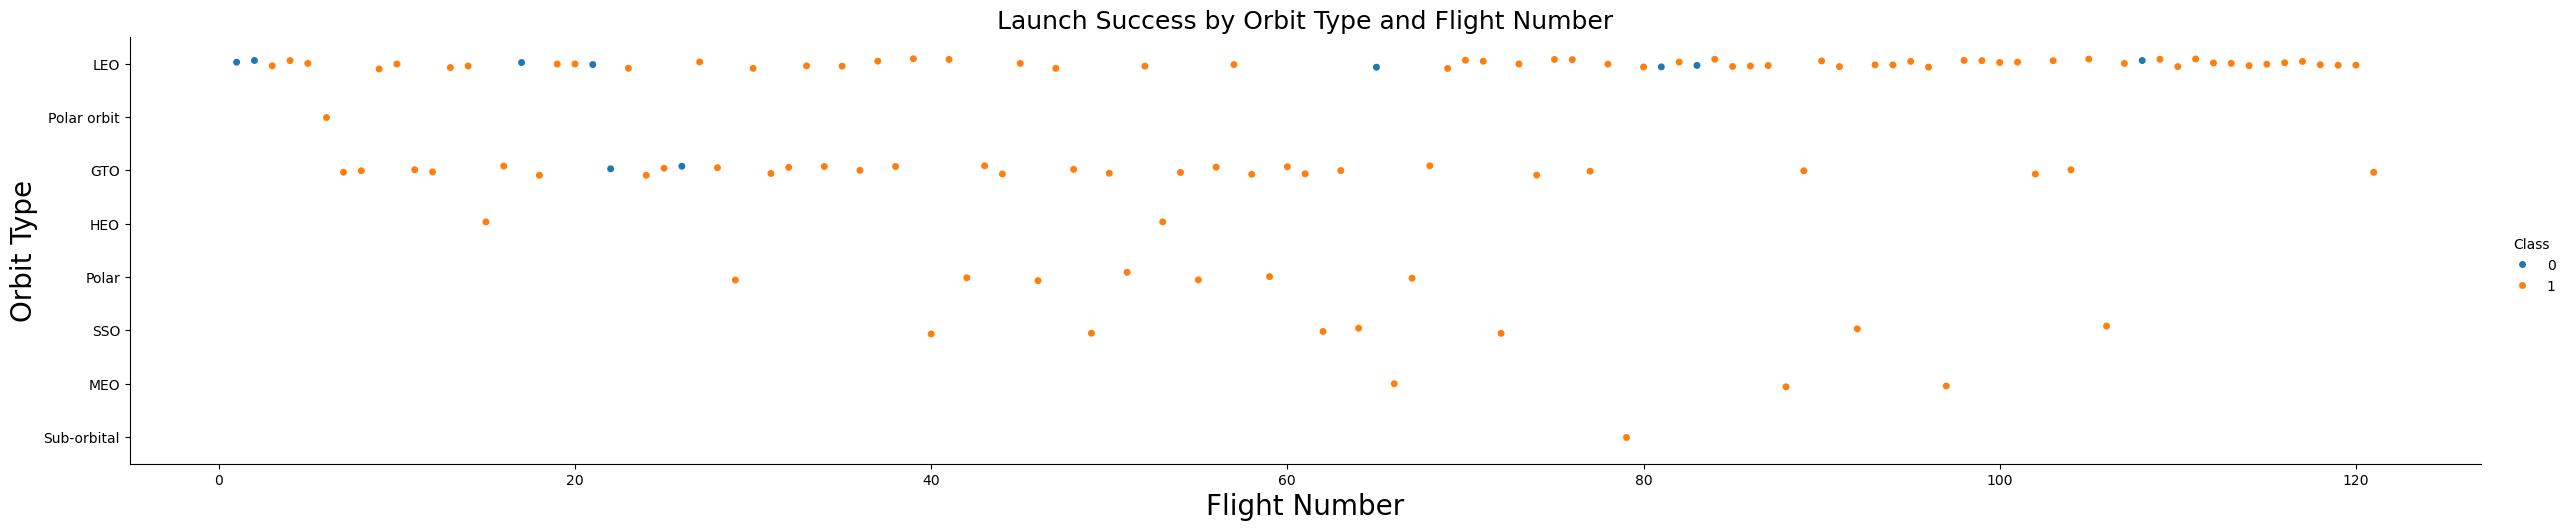

In [12]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
sns.catplot(
    x="Flight No.",
    y="Orbit",
    hue="Class",
    data=df,
    kind="strip",
    aspect=5
)

plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.title("Launch Success by Orbit Type and Flight Number", fontsize=18)

plt.show()

You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


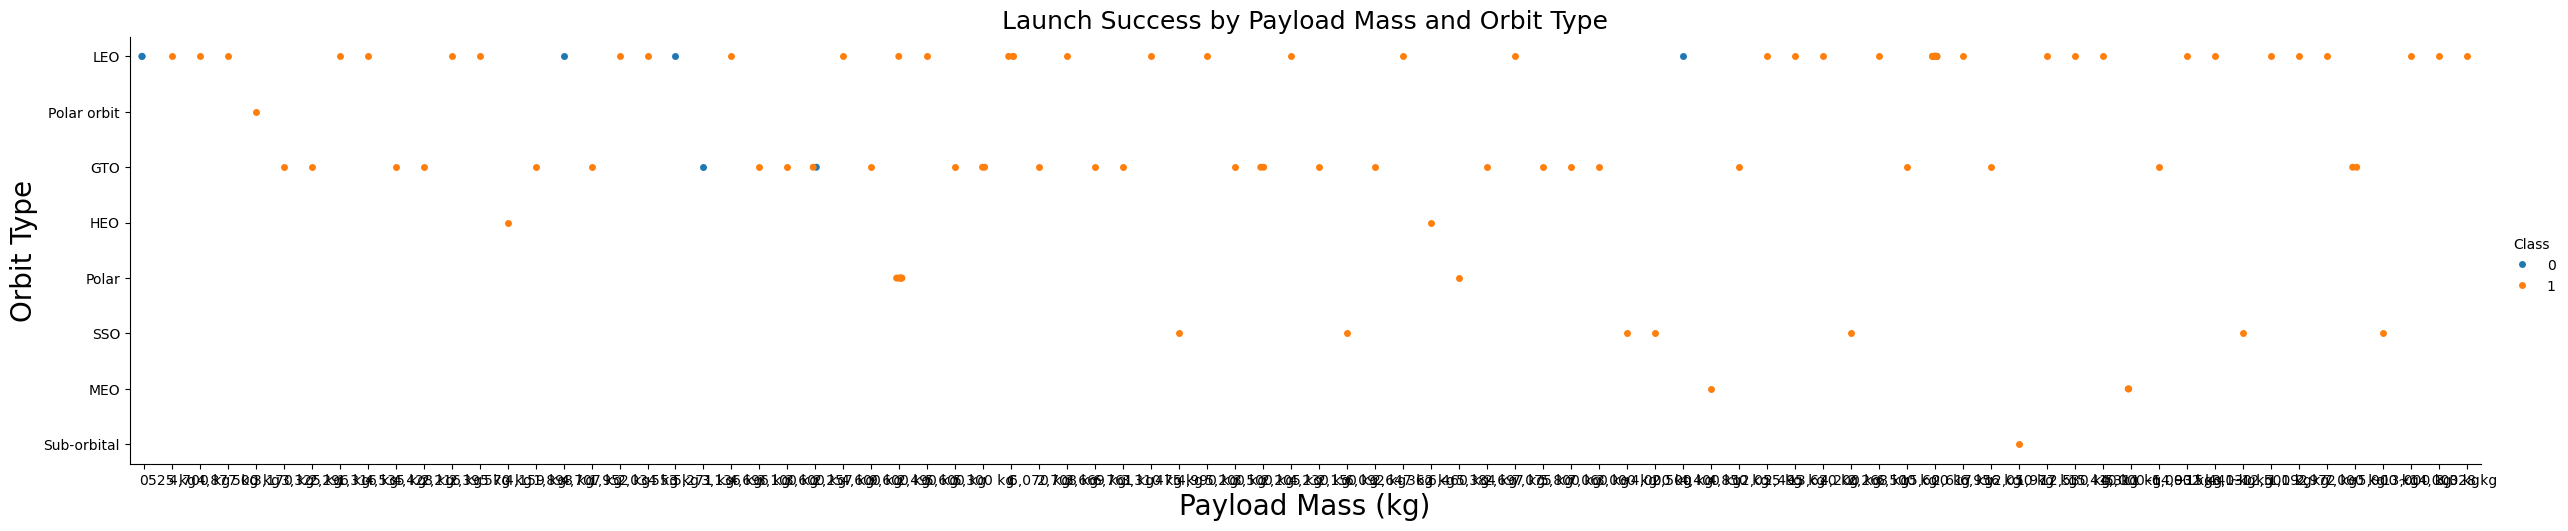

In [13]:
# Plot a scatter point chart with x axis to be Payload and y axis to be the Orbit, and hue to be the class value
sns.catplot(
    x="Payload mass",
    y="Orbit",
    hue="Class",
    data=df,
    kind="strip",
    aspect=5
)

plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.title("Launch Success by Payload Mass and Orbit Type", fontsize=18)

plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.   

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.




### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 


The function will help you get the year from the date:


In [14]:
# Extract year from Date column
year = []

def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year

# Apply function
df["Year"] = Extract_year(df["Date"])

# Calculate yearly average success rate
yearly_success_rate = df.groupby("Year")["Class"].mean().reset_index()

Text(0.5, 1.0, 'Yearly Launch Success Rate Trend')

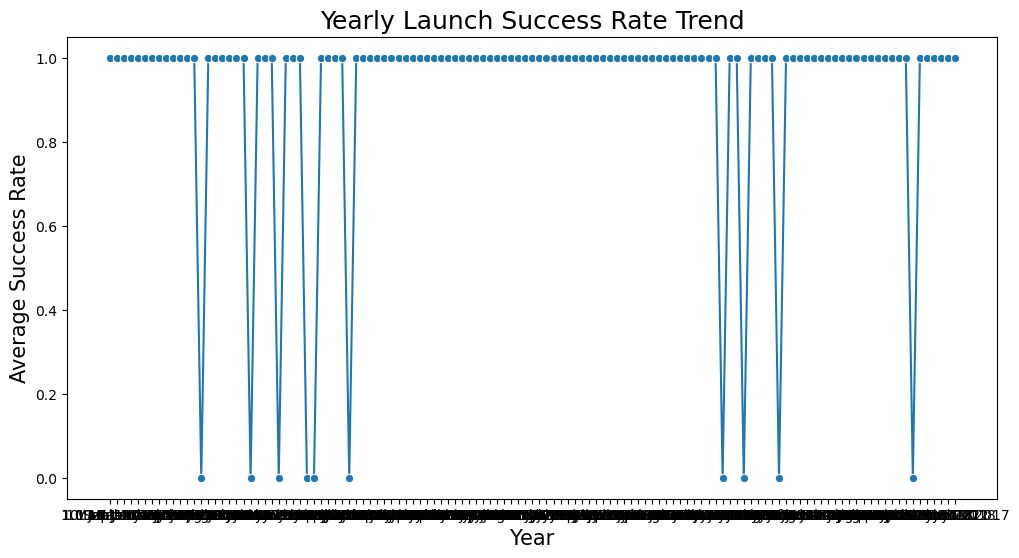

In [15]:
# Plot line chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    x="Year",
    y="Class",
    data=yearly_success_rate,
    marker="o"
)

plt.xlabel("Year", fontsize=15)
plt.ylabel("Average Success Rate", fontsize=15)
plt.title("Yearly Launch Success Rate Trend", fontsize=18)

You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.


## Features Engineering 


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [16]:
features = df[['Flight No.', 'Payload mass', 'Orbit', 'Launch site']]
features.head()

,Flight No.,Payload mass,Orbit,Launch site
0,1,0,LEO,CCAFS
1,2,0,LEO,CCAFS
2,3,525 kg,LEO,CCAFS
3,4,"4,700 kg",LEO,CCAFS
4,5,"4,877 kg",LEO,CCAFS


 ### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [17]:
# HINT: Use get_dummies() function on the categorical columns
# Apply one-hot encoding to categorical columns
features_one_hot = pd.get_dummies(
    features,
    columns=['Orbit', 'Launch site']
)

# Display results
features_one_hot.head()

,Flight No.,Payload mass,Orbit_GTO,Orbit_HEO,Orbit_LEO,Orbit_MEO,Orbit_Polar,Orbit_Polar orbit,Orbit_SSO,Orbit_Sub-orbital,Launch site_CCAFS,Launch site_CCSFS,Launch site_Cape Canaveral,Launch site_KSC,Launch site_VAFB
0,1,0,False,False,True,False,False,False,False,False,True,False,False,False,False
1,2,0,False,False,True,False,False,False,False,False,True,False,False,False,False
2,3,525 kg,False,False,True,False,False,False,False,False,True,False,False,False,False
3,4,"4,700 kg",False,False,True,False,False,False,False,False,True,False,False,False,False
4,5,"4,877 kg",False,False,True,False,False,False,False,False,True,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [18]:
# Clean Payload mass column and convert to numeric
features_one_hot['Payload mass'] = pd.to_numeric(
    features_one_hot['Payload mass']
    .astype(str)
    .str.replace(' kg', '', regex=False)
    .str.replace(',', '', regex=False),
    errors='coerce'
)

# Check if any missing values were created
features_one_hot['Payload mass'].isnull().sum()

np.int64(10)

In [19]:
features_one_hot['Payload mass'] = features_one_hot['Payload mass'].fillna(
    features_one_hot['Payload mass'].mean()
)

In [20]:
# HINT: use astype function
# Cast all columns to float64
features_one_hot = features_one_hot.astype('float64')

# Display the result
features_one_hot.head()


,Flight No.,Payload mass,Orbit_GTO,Orbit_HEO,Orbit_LEO,Orbit_MEO,Orbit_Polar,Orbit_Polar orbit,Orbit_SSO,Orbit_Sub-orbital,Launch site_CCAFS,Launch site_CCSFS,Launch site_Cape Canaveral,Launch site_KSC,Launch site_VAFB
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3.0,525.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,4700.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5.0,4877.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [21]:
features_one_hot.dtypes

Flight No.                    float64
Payload mass                  float64
Orbit_GTO                     float64
Orbit_HEO                     float64
Orbit_LEO                     float64
Orbit_MEO                     float64
Orbit_Polar                   float64
Orbit_Polar orbit             float64
Orbit_SSO                     float64
Orbit_Sub-orbital             float64
Launch site_CCAFS             float64
Launch site_CCSFS             float64
Launch site_Cape Canaveral    float64
Launch site_KSC               float64
Launch site_VAFB              float64
dtype: object

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 


In [21]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Modified markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-10       | 1.1    | Nayef      | updating the input data |


Copyright © 2020 IBM Corporation. All rights reserved.
